In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xml.etree.ElementTree as ET
import xmlschema
import json
import polars as pl
import networkx as nx
from itertools import zip_longest

In [3]:
import ggblab

In [4]:
from ggblab_extra import ConstructionIO
from ggblab_extra import ConstructionTreeParser

In [5]:
from ggblab_extra.sympy import point_from_value, segment_from_command, line_from_value, circle_from_value
from ggblab_extra.sympy import attach_object2d, attach_object3d, enumerate_plane_members

In [6]:
%ggblab api getVersion()

[ggblab] created GeoGebra singleton and stored as 'ggb' in user namespace


'5.2.909.9'

In [7]:
%ggb api newConstruction()

In [8]:
%%ggb
A = Point(xAxis)
B = Point(yAxis)

['A', 'B']

In [9]:
%%ggb
Segment(A, B)

['f']

In [10]:
# %%ggb
# Point(f)
# PathParameter(_)

In [11]:
df = await ConstructionIO.initialize_dataframe(ggb, use_applet=True)
df["Name", "Type", "Command", "Value"]

Name,Type,Command,Value
str,str,str,str
"""A""","""point""","""Point(xAxis)""","""A = (3.31, 0)"""
"""B""","""point""","""Point(yAxis)""","""B = (0, -3.42)"""
"""f""","""segment""","""Segment(A, B)""","""f = 4.7594642555649"""


In [12]:
from sympy import nonlinsolve, linsolve, solve, Eq, discriminant, Matrix, Poly, srepr, pprint, print_tree
from sympy import symbols
x, y, z = symbols('x y z', real=True)

In [13]:
r = await ggb.function('getCommandString', ['f'])
s = segment_from_command(r, df)

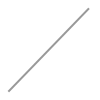

In [14]:
s.evalf()

In [15]:
type(s)

sympy.geometry.line.Segment2D

In [16]:
for e in (await ggb.function('getAllObjectNames')):
    print(await ggb.function('getXML', [e]))

<element type="point" label="A">
	<show object="true" label="true"/>
	<objColor r="21" g="101" b="192" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<animation step="0.1" type="1" playing="false"/>
	<pointSize val="5"/>
	<pointStyle val="0"/>
	<coords x="3.31" y="0" z="1"/>
</element>

<element type="point" label="B">
	<show object="true" label="true"/>
	<objColor r="21" g="101" b="192" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<animation step="0.1" type="1" playing="false"/>
	<pointSize val="5"/>
	<pointStyle val="0"/>
	<coords x="0" y="-3.42" z="1"/>
</element>

<element type="segment" label="f">
	<show object="true" label="true"/>
	<objColor r="0" g="0" b="0" alpha="0"/>
	<layer val="0"/>
	<labelMode val="0"/>
	<lineStyle thickness="5" type="0" typeHidden="1" opacity="178"/>
	<eqnStyle style="implicit"/>
	<outlyingIntersections val="false"/>
	<keepTypeOnTransform val="true"/>
	<startStyle val="default"/>
	<endStyle val="default"/>
	<coords x="3.42" y="-3.31" z="-11

In [17]:
r = await ggb.function('getXML')

In [18]:
root = ET.fromstring(r)
x = ET.tostring(root.find('.//construction'), encoding='unicode')
print(x)

<construction title="" author="" date="">
<command name="Point">
	<input a0="xAxis" />
	<output a0="A" />
</command>
<element type="point" label="A">
	<show object="true" label="true" />
	<objColor r="21" g="101" b="192" alpha="0" />
	<layer val="0" />
	<labelMode val="0" />
	<animation step="0.1" type="1" playing="false" />
	<pointSize val="5" />
	<pointStyle val="0" />
	<coords x="3.31" y="0" z="1" />
</element>
<command name="Point">
	<input a0="yAxis" />
	<output a0="B" />
</command>
<element type="point" label="B">
	<show object="true" label="true" />
	<objColor r="21" g="101" b="192" alpha="0" />
	<layer val="0" />
	<labelMode val="0" />
	<animation step="0.1" type="1" playing="false" />
	<pointSize val="5" />
	<pointStyle val="0" />
	<coords x="0" y="-3.42" z="1" />
</element>
<command name="Segment">
	<input a0="A" a1="B" />
	<output a0="f" />
</command>
<element type="segment" label="f">
	<show object="true" label="true" />
	<objColor r="0" g="0" b="0" alpha="0" />
	<layer val

In [19]:
o = ggb.file.ggb_schema.decode(x)
o

{'@title': '',
 '@author': '',
 '@date': '',
 'command': [{'@name': 'Point',
   'input': {'@a0': 'xAxis'},
   'output': {'@a0': 'A'}},
  {'@name': 'Point', 'input': {'@a0': 'yAxis'}, 'output': {'@a0': 'B'}},
  {'@name': 'Segment',
   'input': {'@a0': 'A', '@a1': 'B'},
   'output': {'@a0': 'f'}}],
 'element': [{'@type': 'point',
   '@label': 'A',
   'show': [{'@object': True, '@label': True}],
   'objColor': [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}],
   'layer': [{'@val': 0}],
   'labelMode': [{'@val': 0}],
   'animation': [{'@step': '0.1', '@type': 1, '@playing': False}],
   'pointSize': [{'@val': 5.0}],
   'pointStyle': [{'@val': 0}],
   'coords': [{'@x': '3.31', '@y': '0', '@z': '1'}]},
  {'@type': 'point',
   '@label': 'B',
   'show': [{'@object': True, '@label': True}],
   'objColor': [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}],
   'layer': [{'@val': 0}],
   'labelMode': [{'@val': 0}],
   'animation': [{'@step': '0.1', '@type': 1, '@playing': False}],
   'pointSize': 

In [20]:
# print(json.dumps(o, indent=None).replace(',', ',\n'))

In [47]:
import jsbeautifier
opts = jsbeautifier.default_options()
opts.indent_size = 2
opts.wrap_line_length = 80
opts.keep_array_indentation = True
opts.brace_style = "preserve-inline"
print(jsbeautifier.beautify(json.dumps(o, indent=None), opts))

{ "@title": "", "@author": "", "@date": "", "command": [
{ "@name": "Point", "input": { "@a0": "xAxis" }, "output": { "@a0": "A" } },
  { "@name": "Point", "input": { "@a0": "yAxis" }, "output": { "@a0": "B" } },
  { "@name": "Segment", "input": { "@a0": "A", "@a1": "B" }, "output": { "@a0": "f" } }], "element": [
  { "@type": "point", "@label": "A", "show": [
  { "@object": true, "@label": true }], "objColor": [
{ "@r": 21, "@g": 101, "@b": 192, "@alpha": 0.0 }], "layer": [
    { "@val": 0 }], "labelMode": [{ "@val": 0 }], "animation": [
    { "@step": "0.1", "@type": 1, "@playing": false }], "pointSize": [
    { "@val": 5.0 }], "pointStyle": [{ "@val": 0 }], "coords": [
    { "@x": "3.31", "@y": "0", "@z": "1" }] },
{ "@type": "point", "@label": "B", "show": [
  { "@object": true, "@label": true }], "objColor": [
{ "@r": 21, "@g": 101, "@b": 192, "@alpha": 0.0 }], "layer": [
    { "@val": 0 }], "labelMode": [{ "@val": 0 }], "animation": [
    { "@step": "0.1", "@type": 1, "@playing":